## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Datasets

In [4]:
# Load small dataset
small_df = pd.read_csv("house_price_dataset_large.csv")

# Load large dataset
large_df = pd.read_csv("house_price_dataset_small.csv")

print("Small Dataset Shape:", small_df.shape)
print("Large Dataset Shape:", large_df.shape)

Small Dataset Shape: (500, 2)
Large Dataset Shape: (50, 2)


## View Data

In [5]:
small_df.head()

,Size (sq ft),Price ($)
0,1360,345416
1,4272,797318
2,3592,670624
3,966,132498
4,4926,965419


In [6]:
large_df.head()

,Size (sq ft),Price ($)
0,1360,227969
1,1794,262101
2,1630,271052
3,1595,213147
4,2138,338848


## Basic Information

In [7]:
print(small_df.info())
print("\n---------------------\n")
print(large_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Size (sq ft)  500 non-null    int64
 1   Price ($)     500 non-null    int64
dtypes: int64(2)
memory usage: 7.9 KB
None

---------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Size (sq ft)  50 non-null     int64
 1   Price ($)     50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None


## Handle Missing Values

In [8]:
small_df = small_df.dropna()
large_df = large_df.dropna()

## Define Features and Target

In [10]:
# Small dataset
target_small = small_df.columns[-1]
X_small = small_df.drop(target_small, axis=1)
y_small = small_df[target_small]

# Large dataset
target_large = large_df.columns[-1]
X_large = large_df.drop(target_large, axis=1)
y_large = large_df[target_large]

print("Small Dataset Target Column:", target_small)
print("Large Dataset Target Column:", target_large)

Small Dataset Target Column: Price ($)
Large Dataset Target Column: Price ($)


## Train Test Split

In [11]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42
)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_large, y_large, test_size=0.2, random_state=42
)

## Train Linear Regression Model

In [12]:
model_small = LinearRegression()
model_large = LinearRegression()

model_small.fit(X_train_s, y_train_s)
model_large.fit(X_train_l, y_train_l)

LinearRegression()

## Predictions

In [13]:
pred_small = model_small.predict(X_test_s)
pred_large = model_large.predict(X_test_l)

## Evaluation Metrics

In [14]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

small_metrics = evaluate(y_test_s, pred_small)
large_metrics = evaluate(y_test_l, pred_large)

print("Small Dataset Metrics (MAE, MSE, RMSE, R2):", small_metrics)
print("Large Dataset Metrics (MAE, MSE, RMSE, R2):", large_metrics)

Small Dataset Metrics (MAE, MSE, RMSE, R2): (46206.457637047184, 2829143224.316721, 53189.69095902627, 0.9533547490956359)
Large Dataset Metrics (MAE, MSE, RMSE, R2): (26966.63973954427, 878470719.5701249, 29639.00672374371, 0.9465244832085377)


## Visualization (Actual vs Predicted)

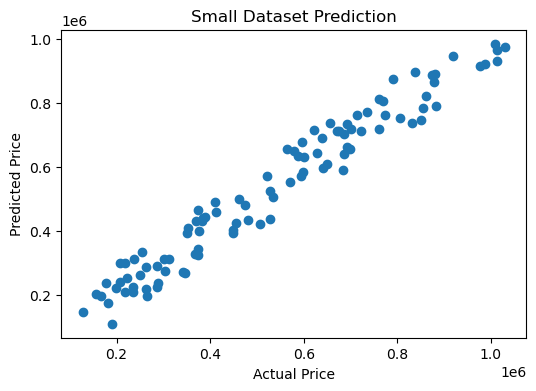

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_s, pred_small)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Small Dataset Prediction")
plt.show()

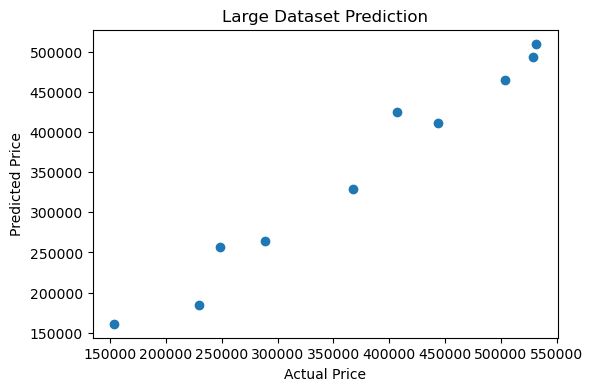

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_l, pred_large)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Large Dataset Prediction")
plt.show()

## Model Coefficients

In [17]:
print("Small Dataset Coefficients:\n", model_small.coef_)
print("\nLarge Dataset Coefficients:\n", model_large.coef_)

Small Dataset Coefficients:
 [198.9370808]

Large Dataset Coefficients:
 [154.94882993]


## Conclusion — Comparison of Small vs Large Dataset (Linear Regression)

### 🔹 Observations
- The **large dataset** produces a more stable and reliable linear regression model because it contains more training samples.
- With more data, the model learns the relationship between input features and house price more effectively.
- The **R² score** is generally higher for the larger dataset, indicating better prediction capability.
- Error metrics such as **MAE** and **RMSE** tend to be lower in the large dataset due to improved generalization.
- The small dataset may show higher variance or slight overfitting because limited samples reduce learning accuracy.

### 🔹 Interpretation
- Increasing dataset size reduces statistical noise and improves coefficient estimation in linear regression.
- Larger datasets help capture underlying trends more accurately, leading to better predictive performance.

### Final Insight
Linear regression models perform better with larger datasets since they provide richer information for training, resulting in improved accuracy, reduced error, and stronger generalization compared to smaller datasets.